# Modeling(1) — Logistic Regression

**전처리:** data_preprocessing_modified_v2 기반  
**실행 순서:** 위에서부터 순서대로 실행

In [1]:
# ① 환경 설정 (코랩 전용)
!apt-get install -y fonts-nanum -qq
!pip install statsmodels -q

from google.colab import drive
drive.mount("/content/drive")
print("완료")


Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Mounted at /content/drive
완료


In [2]:
# ② CSV 경로 설정
CSV_PATH = "/content/drive/MyDrive/2024_청년삶실태조사.csv"

import os
print("✅ 파일 확인" if os.path.exists(CSV_PATH) else "❌ 파일 없음 — 경로 수정 필요")

# Drive 대신 직접 업로드할 경우 아래 주석 해제
# from google.colab import files
# uploaded = files.upload()
# CSV_PATH = list(uploaded.keys())[0]


✅ 파일 확인


In [3]:
# ③ 라이브러리 임포트 & 폰트 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
print("라이브러리 임포트 완료")


라이브러리 임포트 완료


---
## 전처리 함수 (data_preprocessing_modified_v2 기반)

In [4]:
# ④ 전처리 함수 정의
def preprocess_youth_dataset(filepath, model_type="lr"):
    """
    Parameters:
    - filepath: CSV 경로
    - model_type: "lr" (로지스틱 회귀) 또는 "rf" (랜덤 포레스트)
    Returns:
    - X_final, y, ohe_cols (OHE 컬럼명 리스트)
    """
    df = pd.read_csv(filepath, encoding="cp949")
    df.columns = df.columns.str.strip()

    # 타겟 처리 (1:없음→0, 2:있음→1)
    df["Target"] = df["우울증상 유병 여부"].map({1: 0, 2: 1})
    y = df["Target"]

    # 번아웃 컬럼 제거 (leakage 우려)
    drop_cols = ["우울증상 유병 여부", "Target", "최근 1년 소진(번아웃) 경험 여부"]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

    # 파생변수: 현재 근무 여부
    X["현재 근무 여부"] = X["경제활동상태"].apply(lambda x: 1 if x == 1 else 0) if "경제활동상태" in X.columns else 0

    # Ordinal 역순 매핑 (높을수록 긍정/강도 높음)
    ordinal_mappings = {
        "현재 흡연 여부": {4:1, 3:2, 2:3, 1:4},
        "최근 1년간 음주 빈도": {7:0, 1:1, 2:2, 3:3, 4:4, 5:5, 6:6},
        "외식 또는 매식 빈도": {5:0, 4:1, 3:2, 2:3, 1:4},
        "일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다": {5:1,4:2,3:3,2:4,1:5},
        "정치에 대한 관심 정도": {4:1, 3:2, 2:3, 1:4},
        "외출 빈도": {8:1, 7:2, 6:3, 5:4, 4:5, 3:6, 2:7, 1:8},
        "주관적 계층 인식": {5:1, 4:2, 3:3, 2:4, 1:5},
    }
    standard_ordinal_cols = [
        "연령별","가구원수","최종학력","음주 정도","평소 규칙적 운동 여부",
        "고용 계약 기간","총 고용 예상 기간","지난 주 일자리 종사자 수","재직 기간(범위)"
    ]
    if "정규근로시간 외 추가 근무" in X.columns:
        X["정규근로시간 외 추가 근무"] = X["정규근로시간 외 추가 근무"].map({6:1,1:2,2:3,3:4,4:5,5:6,7:1}).fillna(0)
    if "정규 근로일 외 휴일 근무 횟수" in X.columns:
        X["정규 근로일 외 휴일 근무 횟수"] = X["정규 근로일 외 휴일 근무 횟수"].map({0:1,1:2,2:3}).fillna(0)
    for col, mapping in ordinal_mappings.items():
        if col in X.columns:
            X[col] = X[col].fillna(0).map(mapping).fillna(0)
    for col in standard_ordinal_cols:
        if col in X.columns:
            X[col] = X[col].fillna(0)

    # One-Hot Encoding (명목형)
    nominal_cols = [
        "성별","지역별","장애여부","귀하의 현재 재학 상태를 응답해 주십시오.",
        "(복수 응답) 가구유형(1)","국민기초생활보장제도(또는 맞춤형 급여) 수급 여부 및 경험",
        "돌봄 필요 가구원 유무","혼인 상태","부모 동거 여부","공공 임대 주택 거주 경험",
        "현재 주거 점유 형태","최근 1달 동안 같이 식사한 사람",
        "경제활동상태","지난 주 수입을 목적으로 1시간 이상 일한 경험","지난 주 종사상 지위",
        "고용 계약 기간 유무","주휴 수당 수급 여부",
        "정규근로시간 외 추가 근무 시 추가 수당 수급 여부",
        "정규근로일 외 휴일 근무 시 추가 수당 수급 여부",
        "장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)",
        "대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 가족^ 친척",
        "대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 – 이외",
        "현재 연애 여부(유배우 포함)","향후 결혼 계획(유배우 포함)",
        "금융 채무 불이행자(신용불량자)에 해당 여부","현재 근무 여부"
    ]
    valid_nominal = [c for c in nominal_cols if c in X.columns]
    for col in valid_nominal:
        X[col] = X[col].fillna("해당없음").astype(str)
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_ohe = pd.DataFrame(
        ohe.fit_transform(X[valid_nominal]),
        columns=ohe.get_feature_names_out(valid_nominal), index=X.index
    )
    ohe_cols = list(X_ohe.columns)

    # 연속형 log1p 변환
    robust_cols   = ["청년 연간소득 - 총 소득","청년 기준 부채 총액","청년 기준 재산총액"]
    standard_cols = ["월 평균 총생활비"]
    for col in robust_cols + standard_cols:
        if col in X.columns:
            X[col] = np.log1p(X[col].fillna(0))

    # 병합
    X_non_nominal = X.drop(columns=valid_nominal, errors="ignore")
    X_final = pd.concat([X_non_nominal, X_ohe], axis=1)

    # 스케일링 (LR만)
    if model_type == "lr":
        valid_robust = [c for c in robust_cols if c in X_final.columns]
        if valid_robust:
            X_final[valid_robust] = RobustScaler().fit_transform(X_final[valid_robust])
        valid_std = [
            c for c in standard_cols + standard_ordinal_cols + list(ordinal_mappings.keys())
            if c in X_final.columns and c not in valid_robust and c not in ohe_cols
        ]
        if valid_std:
            X_final[valid_std] = StandardScaler().fit_transform(X_final[valid_std])
        print(">> LR용 스케일링 완료 (OHE 컬럼 제외)")
    else:
        print(">> RF용 스케일링 생략")

    print(f"최종 shape — X: {X_final.shape}, y: {y.shape}")
    return X_final, y, ohe_cols

print("전처리 함수 정의 완료")


전처리 함수 정의 완료


In [5]:
# ⑤ 전처리 실행
X_lr, y, ohe_cols = preprocess_youth_dataset(CSV_PATH, model_type="lr")

print("전체 feature 수:", X_lr.shape[1])
print("  - OHE 컬럼:", len(ohe_cols))
print("  - 수치형 컬럼:", X_lr.shape[1]-len(ohe_cols))
print("우울 비율:", round(y.mean()*100,1), "%  (전체", len(y), "명)")
print("결측치 합계:", X_lr.isnull().sum().sum())


>> LR용 스케일링 완료 (OHE 컬럼 제외)
최종 shape — X: (15098, 124), y: (15098,)
전체 feature 수: 124
  - OHE 컬럼: 100
  - 수치형 컬럼: 24
우울 비율: 9.3 %  (전체 15098 명)
결측치 합계: 0


---
## Train / Test Split

In [6]:
# ⑥ Train/Test Split (Stratified)
# 전처리 함수에서 split 제거했으므로 여기서 수행
X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}명  |  Test: {len(X_test):,}명")
print(f"Train 우울 비율: {y_train.mean()*100:.1f}%")
print(f"Test  우울 비율: {y_test.mean()*100:.1f}%")


Train: 12,078명  |  Test: 3,020명
Train 우울 비율: 9.3%
Test  우울 비율: 9.3%


---
## VIF — 근무 관련 컬럼 다중공선성 확인

In [7]:
# ⑦ VIF — 수치형 근무 컬럼 대상 (OHE 제외)
employment_numeric = [
    "정규근로시간 외 추가 근무",
    "정규 근로일 외 휴일 근무 횟수",
    "고용 계약 기간",
    "총 고용 예상 기간",
    "지난 주 일자리 종사자 수",
    "재직 기간(범위)",
    "일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다",
]
vif_cols = [c for c in employment_numeric if c in X_train.columns]

X_vif  = X_train[vif_cols].reset_index(drop=True)
vif_df = pd.DataFrame({
    "feature": vif_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

col_header = "컬럼"
print(f"{col_header:<65} {"VIF":>8}  판단")
print("-"*80)
for _, row in vif_df.iterrows():
    flag = "⚠ 다중공선성" if row["VIF"]>10 else ("주의" if row["VIF"]>5 else "OK")
    fname = row["feature"][:65]
    print(f"{fname:<65} {row['VIF']:>8.2f}  {flag}")

high_n = len(vif_df[vif_df["VIF"]>10])
vif_result = "있음 ⚠" if high_n else "없음 ✅"
print(f"VIF>10: {high_n}개 -> 다중공선성 {vif_result}")


컬럼                                                                     VIF  판단
--------------------------------------------------------------------------------
총 고용 예상 기간                                                            4.00  OK
지난 주 일자리 종사자 수                                                        2.83  OK
재직 기간(범위)                                                             2.71  OK
고용 계약 기간                                                              2.33  OK
일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을     2.27  OK
정규 근로일 외 휴일 근무 횟수                                                     1.95  OK
정규근로시간 외 추가 근무                                                        1.58  OK
VIF>10: 0개 -> 다중공선성 없음 ✅


---
## LR_FULL vs LR_WORK 비교

- **LR_FULL**: 모든 근무 관련 컬럼 포함
- **LR_WORK**: 근무 상세 OHE 컬럼 제거, 만 유지

In [8]:
# ⑧ LR_FULL vs LR_WORK feature 분리
detail_prefixes = [
    "지난 주 종사상 지위_",
    "고용 계약 기간 유무_",
    "주휴 수당 수급 여부_",
    "정규근로시간 외 추가 근무 시 추가 수당 수급 여부_",
    "정규근로일 외 휴일 근무 시 추가 수당 수급 여부_",
    "장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)_",
    "지난 주 수입을 목적으로 1시간 이상 일한 경험_",
]
detail_numeric = [
    "정규근로시간 외 추가 근무",
    "정규 근로일 외 휴일 근무 횟수",
    "고용 계약 기간",
    "총 고용 예상 기간",
    "재직 기간(범위)",
    "일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다",
]

remove_ohe  = [c for c in X_train.columns if any(c.startswith(p) for p in detail_prefixes)]
remove_cols = detail_numeric + remove_ohe
remove_cols = [c for c in remove_cols if c in X_train.columns]

work_feats = [c for c in X_train.columns if c not in remove_cols]
X_train_w  = X_train[work_feats]
X_test_w   = X_test[work_feats]

print("LR_FULL feature 수:", X_train.shape[1])
print("LR_WORK feature 수:", len(work_feats), "( 제거:", len(remove_cols), "개 )")
print("제거된 컬럼 예시:")
for c in remove_cols[:10]:
    print("  -", c)
if len(remove_cols) > 10:
    print("  ... 외", len(remove_cols)-10, "개")

LR_FULL feature 수: 124
LR_WORK feature 수: 93 ( 제거: 31 개 )
제거된 컬럼 예시:
  - 정규근로시간 외 추가 근무
  - 정규 근로일 외 휴일 근무 횟수
  - 고용 계약 기간
  - 총 고용 예상 기간
  - 재직 기간(범위)
  - 일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다
  - 지난 주 수입을 목적으로 1시간 이상 일한 경험_1
  - 지난 주 수입을 목적으로 1시간 이상 일한 경험_2
  - 지난 주 종사상 지위_1.0
  - 지난 주 종사상 지위_2.0
  ... 외 21 개


In [ ]:
# ⑨ 두 버전 학습 및 비교
lr_params = dict(class_weight="balanced", max_iter=1000, random_state=42, C=1.0, solver="lbfgs")

def run_lr(Xtr, Xte, ytr, yte, name):
    m = LogisticRegression(**lr_params).fit(Xtr, ytr)
    yp = m.predict(Xte)
    yb = m.predict_proba(Xte)[:,1]
    return {
        "name": name, "model": m,
        "y_pred": yp, "y_prob": yb,
        "acc":    accuracy_score(yte, yp),
        "prec":   precision_score(yte, yp, zero_division=0),
        "recall": recall_score(yte, yp, zero_division=0),
        "f1":     f1_score(yte, yp, zero_division=0),
        "auc":    roc_auc_score(yte, yb),
        "cm":     confusion_matrix(yte, yp),
        "report": classification_report(yte, yp,
                      target_names=["우울없음","우울있음"], zero_division=0)
    }

print("[LR_FULL] 학습 중...")
res_full = run_lr(X_train,   X_test,   y_train, y_test, "LR_FULL")
print("[LR_WORK] 학습 중...")
res_work = run_lr(X_train_w, X_test_w, y_train, y_test, "LR_WORK")

print(f"  {"지표":<12} {"LR_FULL":>10} {"LR_WORK":>10} {"차이(F-W)":>12}")
print("  " + "-"*48)
for metric, lbl in [("acc","Accuracy"),("prec","Precision"),
                     ("recall","Recall ★"),("f1","F1"),("auc","AUC")]:
    vf, vw = res_full[metric], res_work[metric]
    note   = " <- 근무상세 기여" if abs(vf-vw)>0.01 else ""
    print(f"  {lbl:<12} {vf:>10.4f} {vw:>10.4f} {vf-vw:>+12.4f}{note}")

res_lr   = res_work  # 무조건 LR_WORK 채택
lr_feats = work_feats
adopted  = res_lr["name"]
print(f"\n-> 채택: {adopted}")
print(res_lr["report"])

---
## Step 3. C값 튜닝 — LR_WORK 기준 최적 모델 선정

- 탐색 범위: C = [0.001, 0.01, 0.1, 1, 10]
- 평가 지표: **Recall (핵심)**, F1, ROC-AUC
- 방법: GridSearchCV (StratifiedKFold 5-fold, scoring=recall)

C값별 5-fold CV 성능 비교 (Recall 기준 선정):

         C    Recall      ±        F1      ±       AUC      ±
  ------------------------------------------------------------
     0.001    0.6954 0.0229    0.3344 0.0132    0.8000 0.0140
      0.01    0.7034 0.0243    0.3400 0.0066    0.8068 0.0114  <- 최적
       0.1    0.7025 0.0268    0.3390 0.0089    0.8066 0.0105
       1.0    0.7025 0.0241    0.3384 0.0072    0.8054 0.0104
      10.0    0.7007 0.0250    0.3378 0.0088    0.8050 0.0105

=> 최적 C = 0.01  (CV Recall = 0.7034)

[최적 모델 Test 성능]  C = 0.01
  Accuracy  : 0.7487
  Precision : 0.2368
  Recall    : 0.7651  <- 핵심
  F1-score  : 0.3616
  ROC-AUC   : 0.8208

              precision    recall  f1-score   support

        우울없음       0.97      0.75      0.84      2739
        우울있음       0.24      0.77      0.36       281

    accuracy                           0.75      3020
   macro avg       0.60      0.76      0.60      3020
weighted avg       0.90      0.75      0.80      3020

Confusion Matrix

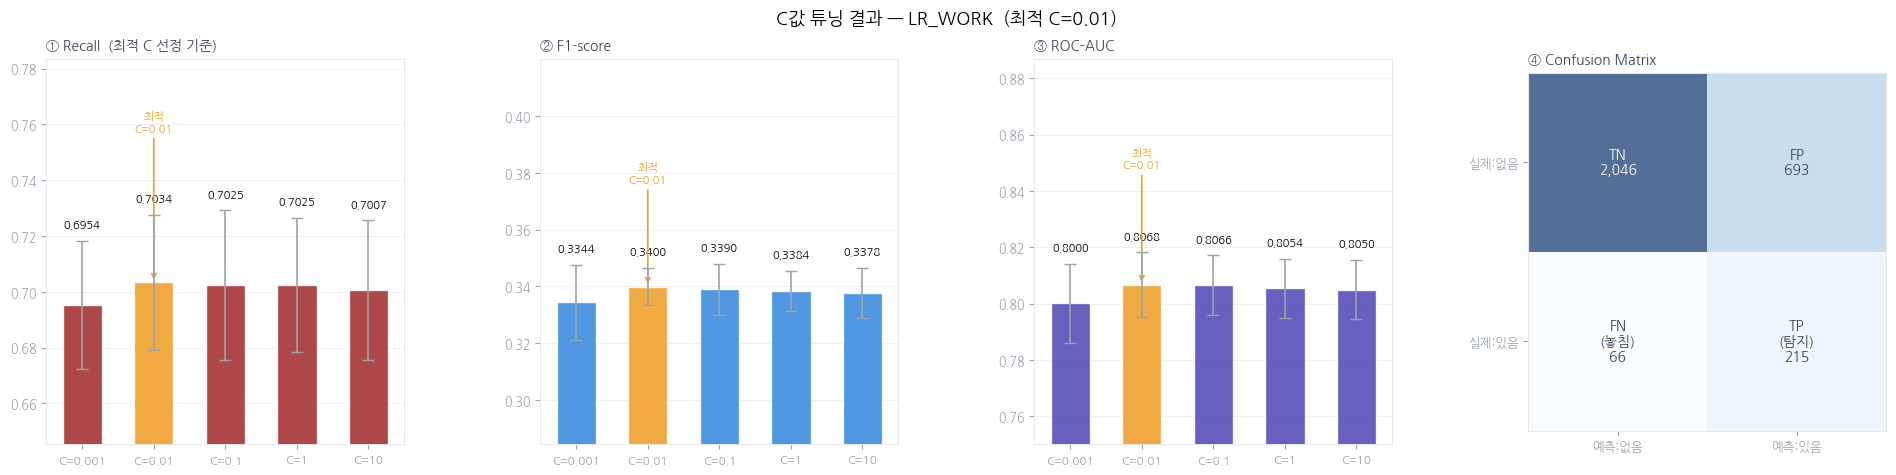

저장 완료: /content/lr_c_tuning.png


In [10]:
# ⑩ Step 3. C값 GridSearch → 최적 모델 확정 → 상위 15개 Feature 선정
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    make_scorer, recall_score, accuracy_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# ════════════════════════════════════════════════════
# STEP 3-1. C값 GridSearch (LR_WORK 기준, Recall 최대화)
# ════════════════════════════════════════════════════
C_values   = [0.001, 0.01, 0.1, 1, 10]
kfold_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    LogisticRegression(
        class_weight="balanced", max_iter=1000,
        random_state=42, solver="lbfgs"
    ),
    param_grid={"C": C_values},
    scoring=make_scorer(recall_score, zero_division=0),  # Recall 기준
    cv=kfold_tune,
    n_jobs=-1,
    refit=True,   # 최적 C로 전체 train 재학습
    verbose=0,
)
grid_search.fit(X_train_w, y_train)
best_C = grid_search.best_params_["C"]

# C값별 성능 비교 출력
results = []
for C_val in C_values:
    m = LogisticRegression(
        C=C_val, class_weight="balanced",
        max_iter=1000, random_state=42, solver="lbfgs"
    )
    rec = cross_val_score(m, X_train_w, y_train, cv=kfold_tune,
                          scoring=make_scorer(recall_score, zero_division=0), n_jobs=-1)
    f1  = cross_val_score(m, X_train_w, y_train, cv=kfold_tune,
                          scoring="f1", n_jobs=-1)
    auc = cross_val_score(m, X_train_w, y_train, cv=kfold_tune,
                          scoring="roc_auc", n_jobs=-1)
    results.append({"C":C_val,
                    "Recall":rec.mean(),"Recall_std":rec.std(),
                    "F1":f1.mean(),     "F1_std":f1.std(),
                    "AUC":auc.mean(),   "AUC_std":auc.std()})

tune_df = pd.DataFrame(results)

print("C값별 5-fold CV 성능 비교 (Recall 기준 선정):")
print(f"\n  {'C':>8}  {'Recall':>8} {'±':>6}  {'F1':>8} {'±':>6}  {'AUC':>8} {'±':>6}")
print("  " + "-"*60)
for _, row in tune_df.iterrows():
    mark = "  <- 최적" if row["C"] == best_C else ""
    print(f"  {row['C']:>8}  {row['Recall']:>8.4f} {row['Recall_std']:>6.4f}"
          f"  {row['F1']:>8.4f} {row['F1_std']:>6.4f}"
          f"  {row['AUC']:>8.4f} {row['AUC_std']:>6.4f}{mark}")
print(f"\n=> 최적 C = {best_C}  (CV Recall = {grid_search.best_score_:.4f})")

# ════════════════════════════════════════════════════
# STEP 3-2. 최적 모델 Test 평가
# ════════════════════════════════════════════════════
best_model = grid_search.best_estimator_
yp_best    = best_model.predict(X_test_w)
yb_best    = best_model.predict_proba(X_test_w)[:, 1]

acc_b  = accuracy_score(y_test, yp_best)
prec_b = precision_score(y_test, yp_best, zero_division=0)
rec_b  = recall_score(y_test, yp_best, zero_division=0)
f1_b   = f1_score(y_test, yp_best, zero_division=0)
auc_b  = roc_auc_score(y_test, yb_best)
cm_b   = confusion_matrix(y_test, yp_best)

print(f"\n[최적 모델 Test 성능]  C = {best_C}")
print("=" * 40)
print(f"  Accuracy  : {acc_b:.4f}")
print(f"  Precision : {prec_b:.4f}")
print(f"  Recall    : {rec_b:.4f}  <- 핵심")
print(f"  F1-score  : {f1_b:.4f}")
print(f"  ROC-AUC   : {auc_b:.4f}")
print("=" * 40)
print()
print(classification_report(y_test, yp_best,
      target_names=["우울없음","우울있음"], zero_division=0))

# Confusion Matrix 출력
print("Confusion Matrix:")
print(f"  TN={cm_b[0,0]:4d}  FP={cm_b[0,1]:4d}")
print(f"  FN={cm_b[1,0]:4d}  TP={cm_b[1,1]:4d}")

# ════════════════════════════════════════════════════
# STEP 3-3. 최적 모델 기준 상위 15개 Feature 선정
# ════════════════════════════════════════════════════
nominal_cols_list = [
    "성별","지역별","장애여부","귀하의 현재 재학 상태를 응답해 주십시오.",
    "(복수 응답) 가구유형(1)","국민기초생활보장제도(또는 맞춤형 급여) 수급 여부 및 경험",
    "돌봄 필요 가구원 유무","혼인 상태","부모 동거 여부","공공 임대 주택 거주 경험",
    "현재 주거 점유 형태","최근 1달 동안 같이 식사한 사람",
    "경제활동상태","지난 주 수입을 목적으로 1시간 이상 일한 경험","지난 주 종사상 지위",
    "고용 계약 기간 유무","주휴 수당 수급 여부",
    "정규근로시간 외 추가 근무 시 추가 수당 수급 여부",
    "정규근로일 외 휴일 근무 시 추가 수당 수급 여부",
    "장시간 근로 경험(퇴근한 후부터 다음 날 출근하기까지의 시간이 11시간 미만)",
    "대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 - 가족^ 친척",
    "대면^ 인터넷(SNS)^ 전화 등의 방식으로 교류하는 사람의 유무 – 이외",
    "현재 연애 여부(유배우 포함)","향후 결혼 계획(유배우 포함)",
    "금융 채무 불이행자(신용불량자)에 해당 여부","현재 근무 여부"
]

def get_original_feature(col_name):
    if col_name not in ohe_cols:
        return col_name
    for nominal_col in nominal_cols_list:
        if col_name.startswith(nominal_col + "_"):
            return nominal_col
    return "_".join(col_name.split("_")[:-1])

# Step 4: coefficient 절댓값
lr_feats = work_feats
coef_best = best_model.coef_[0]
raw_imp = pd.DataFrame({
    "feature":  lr_feats,
    "coef":     coef_best,
    "abs_coef": np.abs(coef_best),
})

# Step 5: OHE → 원본 feature 통합 (|계수| 평균)
raw_imp["original_feature"] = raw_imp["feature"].apply(get_original_feature)
grouped_imp = (
    raw_imp
    .groupby("original_feature", sort=False)
    .agg(
        mean_abs_coef = ("abs_coef", "mean"),
        max_abs_coef  = ("abs_coef", "max"),
        n_ohe_cols    = ("feature",  "count"),
    )
    .reset_index()
    .sort_values("mean_abs_coef", ascending=False)
    .reset_index(drop=True)
)
grouped_imp["rank"] = range(1, len(grouped_imp)+1)

# Step 6: 상위 15개 선정
top15 = grouped_imp.head(15).copy()

print("\n" + "="*60)
print("  최적 모델 기준 상위 15개 Feature (OHE 통합, |계수| 평균)")
print("="*60)
print(f"  {'순위':>4}  {'원본 feature':<50}  {'|계수|평균':>10}  {'OHE수'}")
print("  " + "-"*75)
for _, row in top15.iterrows():
    ohe_mark = f"(x{int(row['n_ohe_cols'])})" if row["n_ohe_cols"] > 1 else "수치형"
    bar = "█" * int(row["mean_abs_coef"] / grouped_imp["mean_abs_coef"].max() * 25)
    print(f"  {int(row['rank']):>4}  {row['original_feature']:<50}"
          f"  {row['mean_abs_coef']:>10.4f}  {ohe_mark:<8}  {bar}")

# 저장
top15.to_csv("/content/lr_feature_importance.csv", index=False, encoding="utf-8-sig")
grouped_imp.to_csv("/content/lr_feature_importance_full.csv", index=False, encoding="utf-8-sig")
print("\n[저장] lr_feature_importance.csv      (Top 15)")
print("[저장] lr_feature_importance_full.csv  (전체)")

# 이후 시각화 셀용 변수 업데이트
res_lr["model"]  = best_model
res_lr["name"]   = f"LR_WORK (C={best_C})"
res_lr["y_pred"] = yp_best
res_lr["y_prob"] = yb_best
res_lr["acc"]    = acc_b
res_lr["prec"]   = prec_b
res_lr["recall"] = rec_b
res_lr["f1"]     = f1_b
res_lr["auc"]    = auc_b
res_lr["cm"]     = cm_b
imp_df   = grouped_imp.rename(columns={"original_feature":"feature","mean_abs_coef":"importance"})
imp_df["coef"] = imp_df["importance"]
top10 = top15  # 시각화 셀 호환
print(f"\n변수 업데이트 완료 -> 이후 셀: LR_WORK (C={best_C})")

# ── 시각화: C값 비교 + Confusion Matrix ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

CC = {"red":"#A32D2D","blue":"#378ADD","teal":"#1D9E75",
      "purple":"#534AB7","amber":"#EF9F27",
      "border":"#E5E7EB","text":"#374151","muted":"#9CA3AF"}

fig = plt.figure(figsize=(20, 5), facecolor="white")
fig.suptitle(f"C값 튜닝 결과 — LR_WORK  (최적 C={best_C})",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(1, 4, wspace=0.38, left=0.05, right=0.97)

def style_c(ax, title=""):
    ax.set_facecolor("white")
    for sp in ax.spines.values(): sp.set_edgecolor(CC["border"])
    ax.tick_params(colors=CC["muted"], labelsize=9)
    if title: ax.set_title(title, fontsize=10, color=CC["text"], pad=7, loc="left")

best_idx = C_values.index(best_C)
for i, (metric, col, title) in enumerate([
    ("Recall", CC["red"],    "① Recall  (최적 C 선정 기준)"),
    ("F1",     CC["blue"],   "② F1-score"),
    ("AUC",    CC["purple"], "③ ROC-AUC"),
]):
    ax = fig.add_subplot(gs[0, i]); style_c(ax, title)
    vals  = tune_df[metric].values
    stds  = tune_df[metric + "_std"].values
    bcolors = [CC["amber"] if j == best_idx else col for j in range(len(C_values))]
    bars = ax.bar(range(len(C_values)), vals, color=bcolors,
                  edgecolor="white", width=0.55, alpha=0.88, zorder=3)
    ax.errorbar(range(len(C_values)), vals, yerr=stds, fmt="none",
                ecolor=CC["muted"], capsize=4, linewidth=1.2, zorder=4)
    for j, (bar, val, std) in enumerate(zip(bars, vals, stds)):
        ax.text(bar.get_x()+bar.get_width()/2, val+std+0.004,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(C_values)))
    ax.set_xticklabels([f"C={c}" for c in C_values], fontsize=8.5)
    ax.set_ylim(max(0, min(vals)-0.05), min(1.05, max(vals)+0.08))
    ax.yaxis.grid(True, color=CC["border"], linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.annotate(f"최적\nC={best_C}",
                xy=(best_idx, vals[best_idx]),
                xytext=(best_idx, vals[best_idx]+stds[best_idx]+0.03),
                ha="center", fontsize=8, color=CC["amber"],
                arrowprops=dict(arrowstyle="->", color=CC["amber"], lw=1.2))

# Confusion Matrix
ax4 = fig.add_subplot(gs[0, 3]); style_c(ax4, "④ Confusion Matrix")
ax4.imshow(cm_b, cmap="Blues", alpha=0.7)
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(["예측:없음","예측:있음"], fontsize=9)
ax4.set_yticklabels(["실제:없음","실제:있음"], fontsize=9)
labels = [["TN","FP"],["FN\n(놓침)","TP\n(탐지)"]]
for i in range(2):
    for j in range(2):
        ct = "white" if cm_b[i,j] > cm_b.max()*0.5 else CC["text"]
        ax4.text(j, i, f"{labels[i][j]}\n{cm_b[i,j]:,}",
                 ha="center", va="center", fontsize=10, fontweight="bold", color=ct)

plt.savefig("/content/lr_c_tuning.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("저장 완료: /content/lr_c_tuning.png")


---
## K-Fold Cross Validation

In [11]:
# ⑪ K-Fold Cross Validation (채택 모델 기준)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_all = X_lr if res_lr["name"]=="LR_FULL" else X_lr[work_feats]

for metric, scorer in [("recall","recall"),("f1","f1"),("roc_auc","roc_auc")]:
    scores = cross_val_score(
        LogisticRegression(**lr_params), X_all, y,
        cv=kfold, scoring=scorer, n_jobs=-1
    )
    print(f"{metric.upper():<10}: {scores.mean():.4f} ± {scores.std():.4f}  (각 fold: {[round(s,4) for s in scores]})")


RECALL    : 0.7171 ± 0.0267  (각 fold: [np.float64(0.7544), np.float64(0.7447), np.float64(0.695), np.float64(0.6975), np.float64(0.694)])
F1        : 0.3459 ± 0.0110  (각 fold: [np.float64(0.3652), np.float64(0.35), np.float64(0.3365), np.float64(0.3353), np.float64(0.3424)])
ROC_AUC   : 0.8092 ± 0.0077  (각 fold: [np.float64(0.8183), np.float64(0.8001), np.float64(0.8182), np.float64(0.8069), np.float64(0.8025)])


---
## 시각화

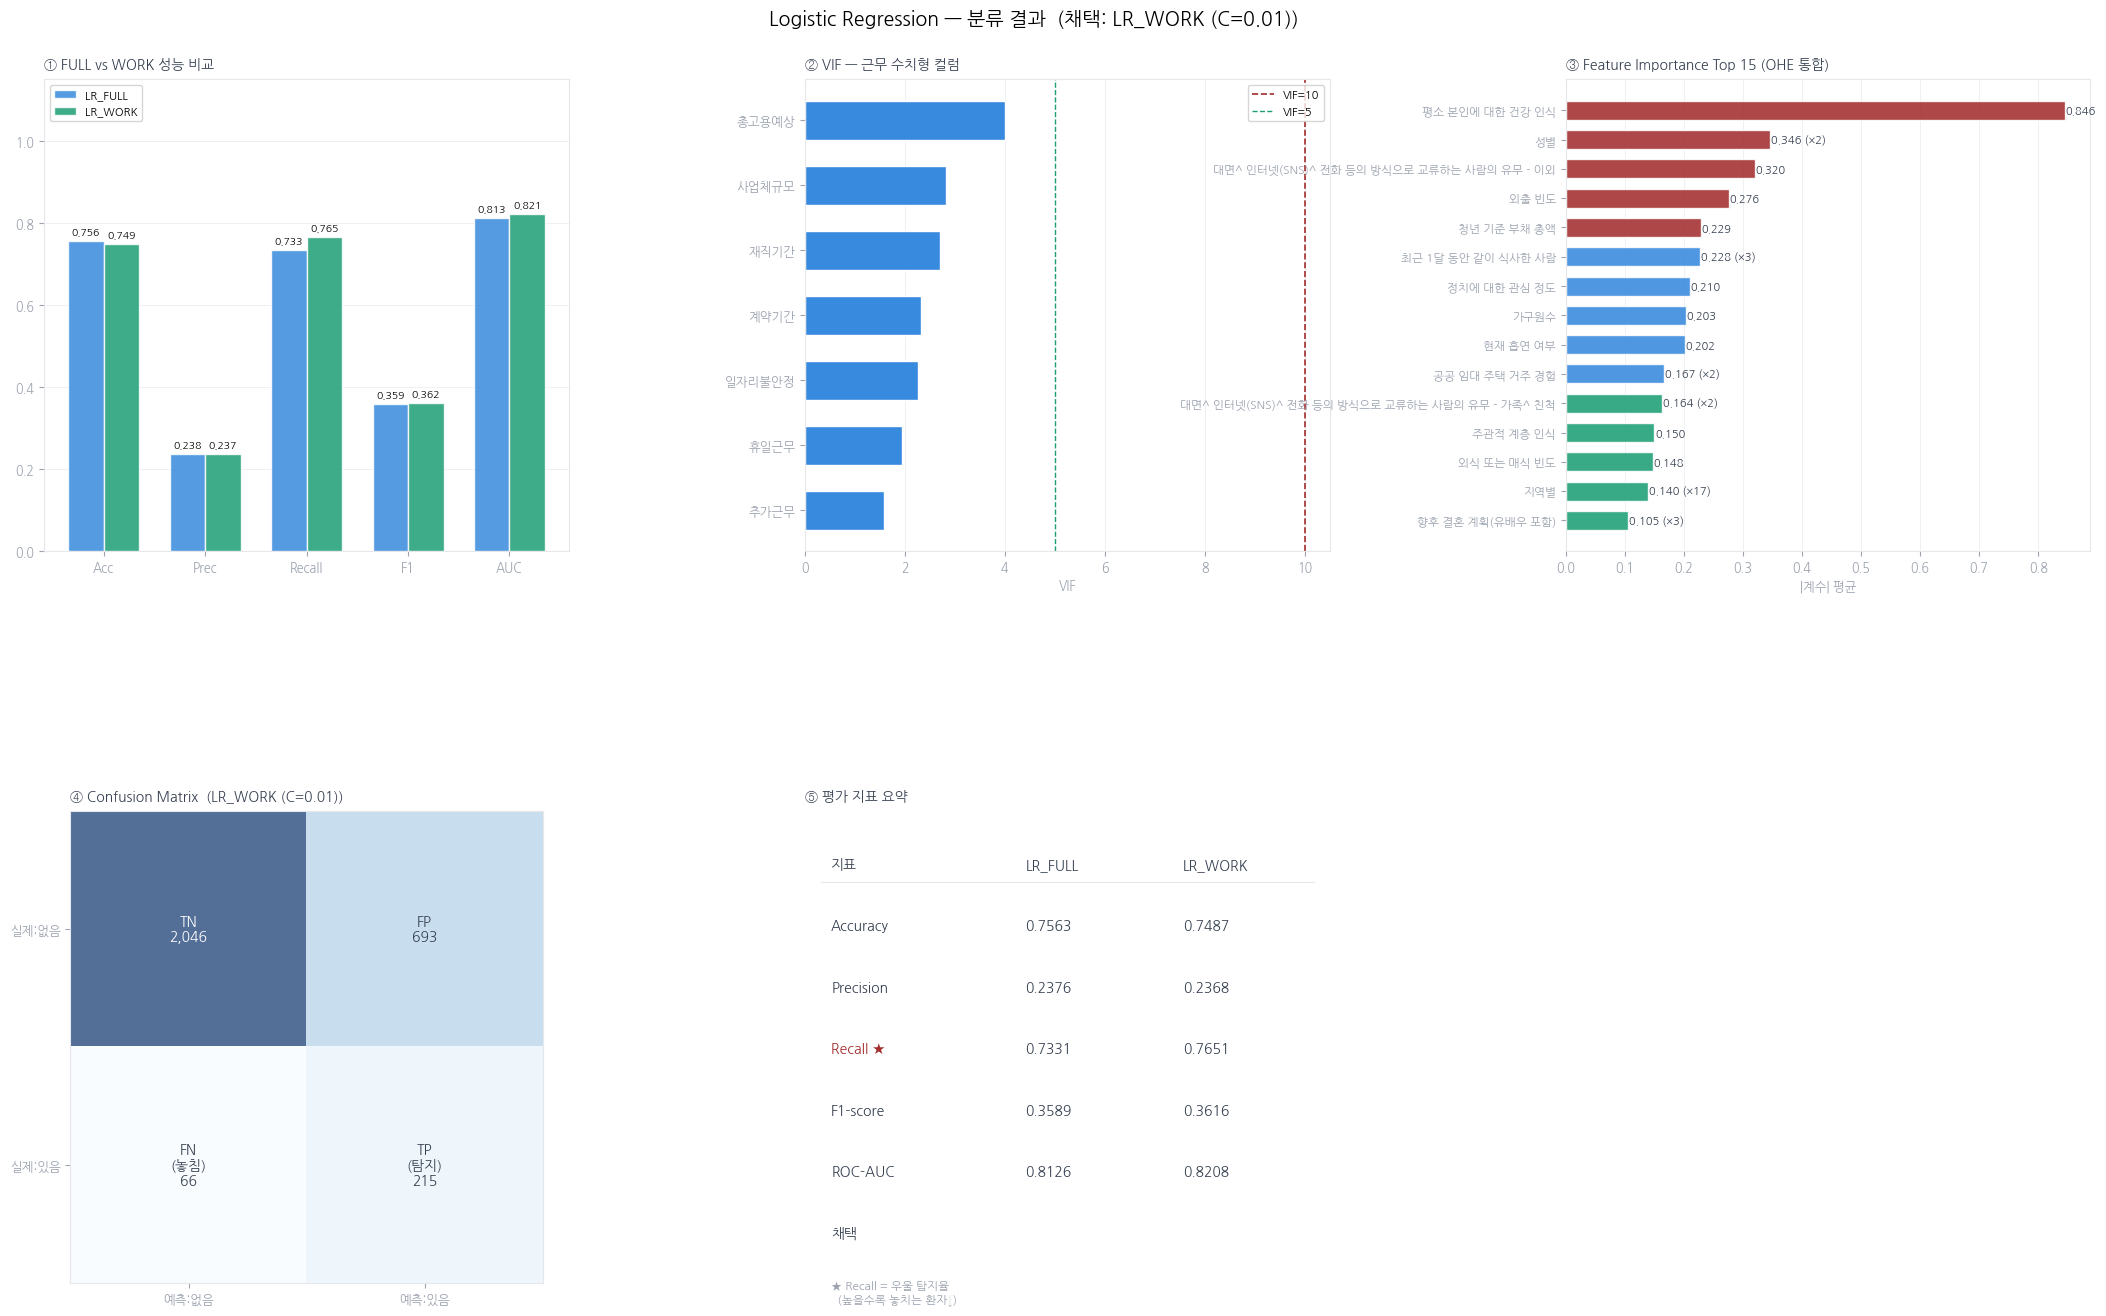

저장 완료: /content/lr_result.png


In [12]:
# ⑬ 시각화 (6개 차트)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

C = {"red":"#A32D2D","blue":"#378ADD","teal":"#1D9E75",
     "border":"#E5E7EB","text":"#374151","muted":"#9CA3AF",
     "purple":"#534AB7","amber":"#EF9F27"}

fig = plt.figure(figsize=(22, 14), facecolor="white")
fig.suptitle("Logistic Regression — 분류 결과  (채택: " + res_lr["name"] + ")",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, hspace=0.55, wspace=0.45,
                       left=0.05, right=0.98, top=0.93, bottom=0.07)

def style(ax, title=""):
    ax.set_facecolor("white")
    for sp in ax.spines.values(): sp.set_edgecolor(C["border"])
    ax.tick_params(colors=C["muted"], labelsize=9)
    if title: ax.set_title(title, fontsize=10, color=C["text"], pad=8, loc="left")

# (1) FULL vs WORK 성능 비교
ax1 = fig.add_subplot(gs[0, 0]); style(ax1, "① FULL vs WORK 성능 비교")
mk = ["acc","prec","recall","f1","auc"]; ml = ["Acc","Prec","Recall","F1","AUC"]
x = np.arange(len(mk)); w = 0.35
for vals, col, lbl, off in [
    ([res_full[m] for m in mk], C["blue"], "LR_FULL", -w/2),
    ([res_work[m] for m in mk], C["teal"], "LR_WORK",  w/2)]:
    bars = ax1.bar(x+off, vals, w, label=lbl, color=col, alpha=0.85, edgecolor="white", zorder=3)
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)
ax1.set_xticks(x); ax1.set_xticklabels(ml, fontsize=9)
ax1.set_ylim(0, 1.15); ax1.legend(fontsize=8, loc="upper left")
ax1.yaxis.grid(True, color=C["border"], linewidth=0.6, alpha=0.7); ax1.set_axisbelow(True)

# (2) VIF 바차트
ax2 = fig.add_subplot(gs[0, 1]); style(ax2, "② VIF — 근무 수치형 컬럼")
short_map = {
    "정규근로시간 외 추가 근무":"추가근무",
    "정규 근로일 외 휴일 근무 횟수":"휴일근무",
    "고용 계약 기간":"계약기간",
    "총 고용 예상 기간":"총고용예상",
    "지난 주 일자리 종사자 수":"사업체규모",
    "재직 기간(범위)":"재직기간",
    "일자리 불안정성 정도 - 현재의 일을 그만두거나 실직하더라도 나는 비슷한 돈을 벌 수 있는 직업을 쉽게 찾을 수 있을 것이다":"일자리불안정",
}
vif_labels = [short_map.get(f, f[:10]) for f in vif_df["feature"]]
vc = [C["red"] if v>10 else C["teal"] if v>5 else C["blue"] for v in vif_df["VIF"]]
ax2.barh(range(len(vif_df)), vif_df["VIF"][::-1], color=vc[::-1], edgecolor="white", height=0.6)
ax2.set_yticks(range(len(vif_df))); ax2.set_yticklabels(vif_labels[::-1], fontsize=9)
ax2.axvline(10, color=C["red"],  linestyle="--", linewidth=1.2, label="VIF=10")
ax2.axvline(5,  color=C["teal"], linestyle="--", linewidth=1.0, label="VIF=5")
ax2.set_xlabel("VIF", fontsize=9, color=C["muted"]); ax2.legend(fontsize=8)
ax2.xaxis.grid(True, color=C["border"], linewidth=0.6, alpha=0.7); ax2.set_axisbelow(True)

# (3) Feature Importance Top 15 (OHE 통합 후)
ax3 = fig.add_subplot(gs[0, 2]); style(ax3, "③ Feature Importance Top 15 (OHE 통합)")
t10 = top10.copy()  # top15
bar_colors3 = [C["red"] if i < 5 else C["blue"] if i < 10 else C["teal"] for i in range(len(t10))]
ax3.barh(range(len(t10)), t10["mean_abs_coef"][::-1].values,
         color=bar_colors3[::-1], edgecolor="white", height=0.65, alpha=0.88)
ax3.set_yticks(range(len(t10)))
ax3.set_yticklabels(t10["original_feature"][::-1].values, fontsize=8.5)
ax3.set_xlabel("|계수| 평균", fontsize=9, color=C["muted"])
for bar, val, n in zip(ax3.patches,
                       t10["mean_abs_coef"][::-1].values,
                       t10["n_ohe_cols"][::-1].values):
    label = f"{val:.3f}" + (f" (×{int(n)})".replace(" (×1)",""))
    ax3.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
             label, va="center", fontsize=8, color=C["text"])
ax3.xaxis.grid(True, color=C["border"], linewidth=0.6, alpha=0.7); ax3.set_axisbelow(True)

# (4) Confusion Matrix
ax4 = fig.add_subplot(gs[1, 0]); style(ax4, "④ Confusion Matrix  (" + res_lr["name"] + ")")
ax4.imshow(res_lr["cm"], cmap="Blues", alpha=0.7)
ax4.set_xticks([0, 1]); ax4.set_yticks([0, 1])
ax4.set_xticklabels(["예측:없음","예측:있음"], fontsize=9)
ax4.set_yticklabels(["실제:없음","실제:있음"], fontsize=9)
lbls = [["TN","FP"],["FN\n(놓침)","TP\n(탐지)"]]
for i in range(2):
    for j in range(2):
        ct = "white" if res_lr["cm"][i,j] > res_lr["cm"].max()*0.5 else C["text"]
        cm_label = lbls[i][j] + "\n" + f"{res_lr['cm'][i,j]:,}"
        ax4.text(j, i, cm_label,
                 ha="center", va="center", fontsize=10, fontweight="bold", color=ct)

# (6) 지표 요약
ax6 = fig.add_subplot(gs[1, 1]); ax6.axis("off"); style(ax6, "⑤ 평가 지표 요약")
rows = [("지표",    "LR_FULL",                    "LR_WORK"),
        ("Accuracy",  f"{res_full['acc']:.4f}",    f"{res_work['acc']:.4f}"),
        ("Precision", f"{res_full['prec']:.4f}",   f"{res_work['prec']:.4f}"),
        ("Recall ★",  f"{res_full['recall']:.4f}", f"{res_work['recall']:.4f}"),
        ("F1-score",  f"{res_full['f1']:.4f}",     f"{res_work['f1']:.4f}"),
        ("ROC-AUC",   f"{res_full['auc']:.4f}",    f"{res_work['auc']:.4f}"),
        ("채택",
         "← " if res_lr["name"]=="LR_FULL" else "",
         "← " if res_lr["name"]=="LR_WORK" else "")]
yp = 0.90
for ri, row in enumerate(rows):
    for ci, (val, xp) in enumerate(zip(row, [0.05, 0.42, 0.72])):
        fc = C["red"] if ("★" in val or "←" in val) else C["text"]
        ax6.text(xp, yp, val, transform=ax6.transAxes,
                 fontsize=10, fontweight="bold" if ri==0 else "normal",
                 color=fc, va="top")
    if ri == 0:
        line = plt.Line2D([0.03, 0.97], [yp-0.05, yp-0.05],
                          transform=ax6.transAxes, color=C["border"], linewidth=0.8)
        ax6.add_line(line)
    yp -= 0.13
ax6.text(0.05, yp-0.03,
         "★ Recall = 우울 탐지율\n  (높을수록 놓치는 환자↓)",
         transform=ax6.transAxes, fontsize=8.5, color=C["muted"])

plt.savefig("/content/lr_result.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("저장 완료: /content/lr_result.png")

In [13]:
# ⑭ 결과 파일 다운로드
from google.colab import files
files.download("/content/lr_feature_importance.csv")       # Top 10
files.download("/content/lr_feature_importance_full.csv")  # 전체 순위
files.download("/content/lr_result.png")
files.download("/content/lr_c_tuning.png")
print("다운로드 완료")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드 완료
